In [90]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

### Load Diabetes Dataset

In [91]:
# Load dataset
df=pd.read_csv('Dataset of Diabetes .csv')
df

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,200,454317,M,71,11.0,97,7.0,7.5,1.7,1.2,1.8,0.6,30.0,Y
996,671,876534,M,31,3.0,60,12.3,4.1,2.2,0.7,2.4,15.4,37.2,Y
997,669,87654,M,30,7.1,81,6.7,4.1,1.1,1.2,2.4,8.1,27.4,Y
998,99,24004,M,38,5.8,59,6.7,5.3,2.0,1.6,2.9,14.0,40.5,Y


### Analyses the Dataset

In [92]:
# Check dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   str    
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   str    
dtypes: float64(8), int64(4), str(2)
memory usage: 109.5 KB


In [93]:
df.head(10)

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N
5,634,34224,F,45,2.3,24,4.0,2.9,1.0,1.0,1.5,0.4,21.0,N
6,721,34225,F,50,2.0,50,4.0,3.6,1.3,0.9,2.1,0.6,24.0,N
7,421,34227,M,48,4.7,47,4.0,2.9,0.8,0.9,1.6,0.4,24.0,N
8,670,34229,M,43,2.6,67,4.0,3.8,0.9,2.4,3.7,1.0,21.0,N
9,759,34230,F,32,3.6,28,4.0,3.8,2.0,2.4,3.8,1.0,24.0,N


In [94]:
# Numerical columns
num_cols=df.select_dtypes(include=[np.number]).drop(columns=['ID', 'No_Pation']).columns.to_list()
num_cols

['AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']

In [95]:
# Describe all numerical columns without 'ID', 'No_Pation'
df[num_cols].describe()

,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,53.528000,5.124743,68.943000,8.281160,4.862820,2.349610,1.204750,2.609790,1.854700,29.578020
std,8.799241,2.935165,59.984747,2.534003,1.301738,1.401176,0.660414,1.115102,3.663599,4.962388
min,20.000000,0.500000,6.000000,0.900000,0.000000,0.300000,0.200000,0.300000,0.100000,19.000000
25%,51.000000,3.700000,48.000000,6.500000,4.000000,1.500000,0.900000,1.800000,0.700000,26.000000
50%,55.000000,4.600000,60.000000,8.000000,4.800000,2.000000,1.100000,2.500000,0.900000,30.000000
75%,59.000000,5.700000,73.000000,10.200000,5.600000,2.900000,1.300000,3.300000,1.500000,33.000000
max,79.000000,38.900000,800.000000,16.000000,10.300000,13.800000,9.900000,9.900000,35.000000,47.750000


### Drop 'ID' & 'No_Pation' columns

In [96]:
df=df.drop(columns=['ID', 'No_Pation'])
df.head()


,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


### Analyses the string columns & Data Cleaning

In [97]:
# Gender is a sting columns so check the unique value of gender
print(f'unique values:{df['Gender'].unique()}') 
print(f'number of unique values: {df['Gender'].nunique()}')
print(f'Value Count: {df['Gender'].value_counts()}')

unique values:<StringArray>
['F', 'M', 'f']
Length: 3, dtype: str
number of unique values: 3
Value Count: Gender
M    565
F    434
f      1
Name: count, dtype: int64


In [98]:
# Change data lowercase to uppercase
df['Gender']=df['Gender'].str.upper()
print(f'unique values:{df['Gender'].unique()}') 
print(f'number of unique values: {df['Gender'].nunique()}')
print(f'Value Count: {df['Gender'].value_counts()}')

unique values:<StringArray>
['F', 'M']
Length: 2, dtype: str
number of unique values: 2
Value Count: Gender
M    565
F    435
Name: count, dtype: int64


In [99]:
# Change Male-> 1 and Female -> 0
df['Gender'] = df['Gender'].map({'F': 0, 'M': 1})
df.head()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,1,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,1,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [100]:
# CLASS is a sting columns so check the unique value of CLASS
print(f'unique values:{df['CLASS'].unique()}') 
print(f'number of unique values: {df['CLASS'].nunique()}')
print(f'Value Count: {df['CLASS'].value_counts()}')

unique values:<StringArray>
['N', 'N ', 'P', 'Y', 'Y ']
Length: 5, dtype: str
number of unique values: 5
Value Count: CLASS
Y     840
N     102
P      53
Y       4
N       1
Name: count, dtype: int64


In [101]:
#Remove whitespace 
df['CLASS']=df['CLASS'].str.strip()
print(f'unique values:{df['CLASS'].unique()}') 
print(f'number of unique values: {df['CLASS'].nunique()}')
print(f'Value Count: {df['CLASS'].value_counts()}')

unique values:<StringArray>
['N', 'P', 'Y']
Length: 3, dtype: str
number of unique values: 3
Value Count: CLASS
Y    844
N    103
P     53
Name: count, dtype: int64


### Identify the features and target values

In [102]:
# Define feature and target columns
target='CLASS'
X=df.drop(columns=[target])
y=df[target]

In [103]:
X

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
0,0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0
1,1,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0
2,0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0
3,0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0
4,1,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0
...,...,...,...,...,...,...,...,...,...,...,...
995,1,71,11.0,97,7.0,7.5,1.7,1.2,1.8,0.6,30.0
996,1,31,3.0,60,12.3,4.1,2.2,0.7,2.4,15.4,37.2
997,1,30,7.1,81,6.7,4.1,1.1,1.2,2.4,8.1,27.4
998,1,38,5.8,59,6.7,5.3,2.0,1.6,2.9,14.0,40.5


In [104]:
y

0      N
1      N
2      N
3      N
4      N
      ..
995    Y
996    Y
997    Y
998    Y
999    Y
Name: CLASS, Length: 1000, dtype: str

In [105]:
# Y-> diabetic, N-> non-diabetic, P-> pre-diabetic
print(y.value_counts(normalize=True) * 100)

CLASS
Y    84.4
N    10.3
P     5.3
Name: proportion, dtype: float64


### Data Visualization of Target values

Text(0, 0.5, 'Count')

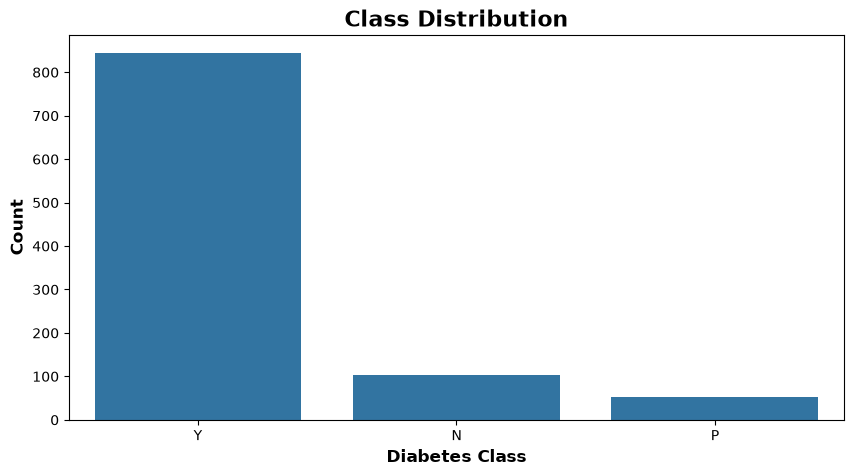

In [106]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x=target, order=y.value_counts().index)
plt.title('Class Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Diabetes Class', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')


### Visualize features vs target

In [107]:
num_cols

['AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']

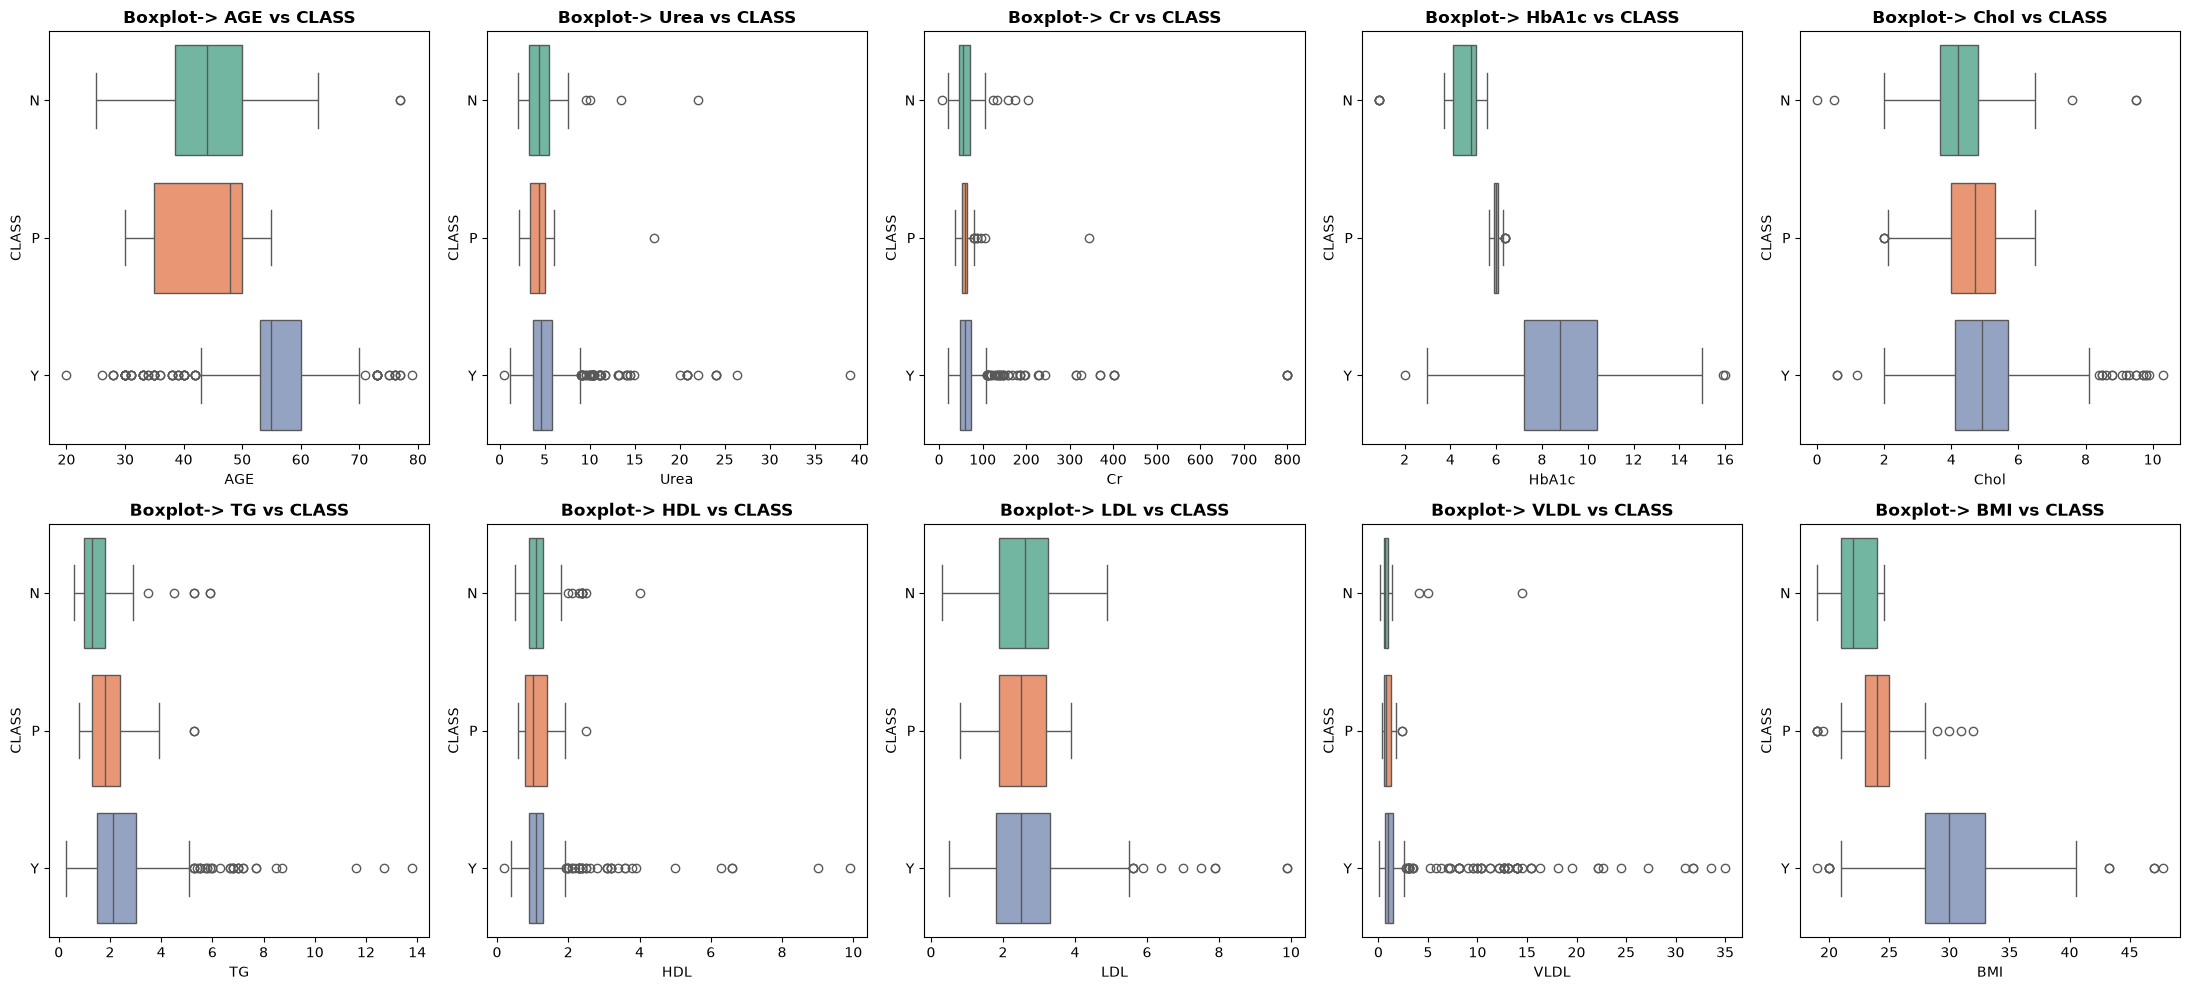

In [108]:
fig, ax=plt.subplots(2,5,figsize=(22,10))
ax = ax.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x=col, y='CLASS', hue='CLASS', ax=ax[i], palette="Set2")
    ax[i].set_title(f'Boxplot-> {col} vs CLASS', fontweight='bold')

plt.tight_layout()
plt.show()


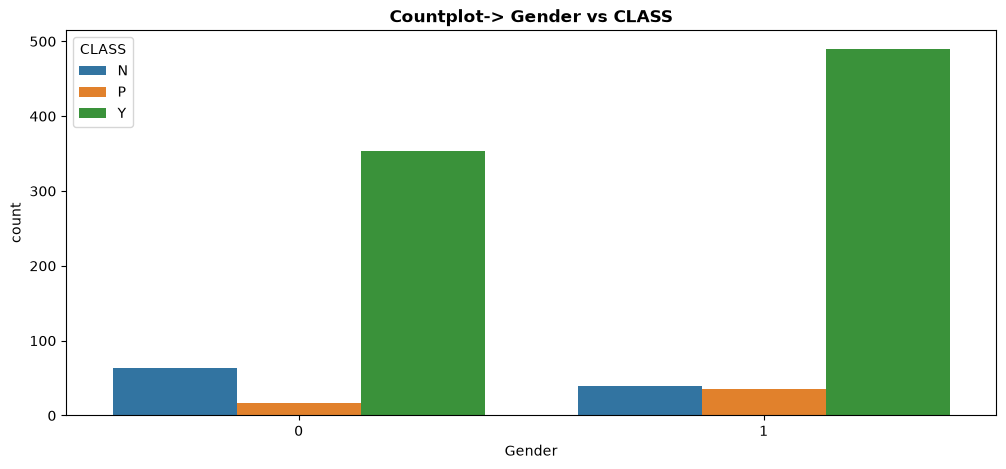

In [109]:
# Gender vs  CLASS
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='Gender', hue='CLASS', palette='tab10')
plt.title('Countplot-> Gender vs CLASS', fontweight='bold')
plt.show()

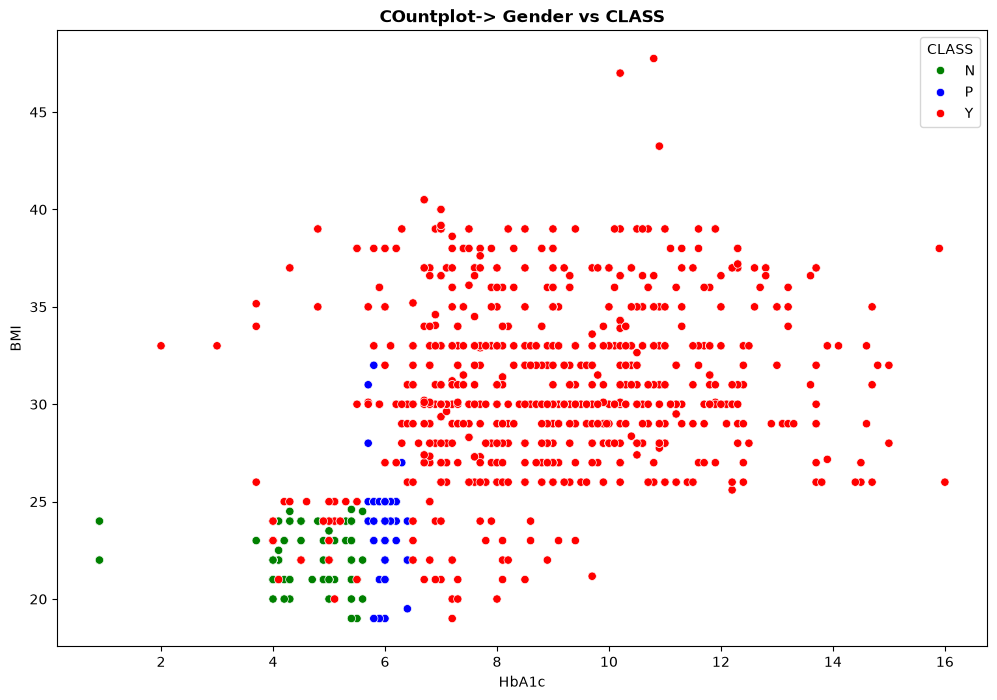

In [110]:
# HbA1c vs BMI 
plt.figure(figsize=(12,8))
sns.scatterplot(data=df, x='HbA1c', y='BMI',hue='CLASS', palette={'N': 'green', 'P': 'blue', 'Y': 'red'})
plt.title('COuntplot-> Gender vs CLASS', fontweight='bold')
plt.show()

### Train Test Split

In [115]:
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (800, 11)
Test shape: (200, 11)


### Decision Tree Training

In [116]:
model= DecisionTreeClassifier(max_depth=3,criterion='gini', random_state=42)
model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 